In [1]:
import pandas as pd
import numpy as np
import scipy
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import sys

sys.path.append("../src")

In [3]:
from data_utils import (
    load_ohlcv,
    validate_ohlcv,
    compute_returns,
    performance_metrics
)

In [4]:
market_data_test = load_ohlcv("../data")

market_data_test.head()

,date,open,high,low,close,adjusted_close,volume,ticker
0,2020-01-02,74.059998,75.150002,73.797501,75.087502,72.271545,135480400,AAPL
1,2020-01-03,74.287498,75.144997,74.125000,74.357498,71.568909,146322800,AAPL
2,2020-01-06,73.447502,74.989998,73.187500,74.949997,72.139198,118387200,AAPL
3,2020-01-07,74.959999,75.224998,74.370003,74.597504,71.799911,108872000,AAPL
4,2020-01-08,74.290001,76.110001,74.290001,75.797501,72.954918,132079200,AAPL


In [5]:
print("Rows:", len(market_data_test))
print("Tickers:", market_data_test["ticker"].nunique())

Rows: 46717
Tickers: 31


In [6]:
market_data_test.to_csv(
    "../data/cleaned_market_data.csv",
    index=False
)

In [7]:
market_data_test["daily_return"] = (
    market_data_test
    .groupby("ticker")["adjusted_close"]
    .pct_change()
)

In [8]:
extreme_returns = market_data_test[
    market_data_test["daily_return"].abs() > 0.20
]

print("Extreme return rows:", len(extreme_returns))

Extreme return rows: 19


In [9]:
extreme_returns[
    ["date", "ticker", "adjusted_close", "daily_return"]
]

,date,ticker,adjusted_close,daily_return
2831,2025-04-09,AMD,96.839996,0.238205
2954,2025-10-06,AMD,203.710007,0.237080
5767,2024-12-13,AVGO,221.375992,0.244326
10601,2020-03-18,CVX,41.820549,-0.221248
10605,2020-03-24,CVX,50.556904,0.227407
19237,2024-08-02,INTC,21.344599,-0.260585
19519,2025-09-18,INTC,30.570000,0.227711
26146,2022-02-03,META,235.690262,-0.263901
26330,2022-10-27,META,97.087425,-0.245571
26396,2023-02-02,META,187.126740,0.232824


In [10]:
market_data_test["volume_20d_avg"] = (
    market_data_test
    .groupby("ticker")["volume"]
    .transform(lambda x: x.rolling(20).mean())
)

In [11]:
market_data_test["volume_ratio"] = (
    market_data_test["volume"] /
    market_data_test["volume_20d_avg"]
)

In [12]:
volume_spikes = market_data_test[
    market_data_test["volume_ratio"] > 5
]

print("Volume spike rows:", len(volume_spikes))

Volume spike rows: 21


In [13]:
quality_report = validate_ohlcv(
    market_data_test
)

quality_report

{'missing_values': np.int64(0),
 'duplicate_rows': np.int64(0),
 'invalid_prices': np.int64(0),
 'negative_volume': np.int64(0),
 'invalid_ohlc': np.int64(0)}

In [14]:
quality_summary = pd.DataFrame({
    "check": [
        "Missing values",
        "Duplicate ticker-date rows",
        "Invalid prices",
        "Negative volume",
        "Invalid OHLC rows",
        "Extreme daily returns (>20%)",
        "Volume spikes (>5x 20-day average)"
    ],
    "count": [
        0,
        0,
        0,
        0,
        0,
        19,
        21
    ],
    "decision": [
        "No action needed",
        "No action needed",
        "No action needed",
        "No action needed",
        "No action needed",
        "Reviewed and retained",
        "Reviewed and retained"
    ]
})

quality_summary

,check,count,decision
0,Missing values,0,No action needed
1,Duplicate ticker-date rows,0,No action needed
2,Invalid prices,0,No action needed
3,Negative volume,0,No action needed
4,Invalid OHLC rows,0,No action needed
5,Extreme daily returns (>20%),19,Reviewed and retained
6,Volume spikes (>5x 20-day average),21,Reviewed and retained


In [15]:
quality_summary.to_csv(
    "../reports/data_quality_report.csv",
    index=False
)

In [16]:
daily_returns = compute_returns(
    market_data_test,
    frequency="daily"
)

selected_tickers = ["AAPL", "NVDA", "TSLA", "JPM", "SPY"]

plot_data = daily_returns[
    daily_returns["ticker"].isin(selected_tickers)
]

plot_data.head()

,date,open,high,low,close,adjusted_close,volume,ticker,daily_return,volume_20d_avg,volume_ratio,simple_return,log_return
0,2020-01-02,74.059998,75.150002,73.797501,75.087502,72.271545,135480400,AAPL,NaN,NaN,NaN,NaN,NaN
1,2020-01-03,74.287498,75.144997,74.125000,74.357498,71.568909,146322800,AAPL,-0.009722,NaN,NaN,-0.009722,-0.009770
2,2020-01-06,73.447502,74.989998,73.187500,74.949997,72.139198,118387200,AAPL,0.007968,NaN,NaN,0.007968,0.007937
3,2020-01-07,74.959999,75.224998,74.370003,74.597504,71.799911,108872000,AAPL,-0.004703,NaN,NaN,-0.004703,-0.004714
4,2020-01-08,74.290001,76.110001,74.290001,75.797501,72.954918,132079200,AAPL,0.016086,NaN,NaN,0.016086,0.015958


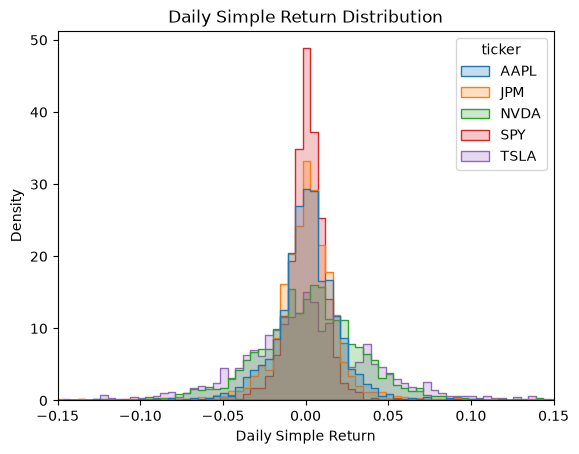

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(
    data=plot_data,
    x="simple_return",
    hue="ticker",
    bins=100,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Daily Simple Return Distribution")
plt.xlabel("Daily Simple Return")
plt.ylabel("Density")
plt.xlim(-0.15, 0.15)

plt.savefig(
    "../reports/daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
weekly_returns = compute_returns(
    market_data_test,
    frequency="weekly"
)

weekly_returns.head()

,ticker,date,simple_return,log_return
0,AAPL,2020-01-03,-0.009722,-0.009770
1,AAPL,2020-01-10,0.043372,0.042458
2,AAPL,2020-01-17,0.027068,0.026708
3,AAPL,2020-01-24,-0.001318,-0.001318
4,AAPL,2020-01-31,-0.027646,-0.028036


In [19]:
monthly_returns = compute_returns(
    market_data_test,
    frequency="monthly"
)

monthly_returns.head()

,ticker,date,simple_return,log_return
0,AAPL,2020-01-31,0.030497,0.030042
1,AAPL,2020-02-29,-0.114701,-0.121830
2,AAPL,2020-03-31,-0.069761,-0.072314
3,AAPL,2020-04-30,0.155373,0.144424
4,AAPL,2020-05-31,0.085095,0.081667


In [20]:
daily_returns["rolling_volatility_21d"] = (
    daily_returns
    .groupby("ticker")["simple_return"]
    .transform(
        lambda x: x.rolling(21).std() * np.sqrt(252)
    )
)

In [21]:
daily_returns[
    daily_returns["ticker"] == "AAPL"
][
    ["date", "simple_return", "rolling_volatility_21d"]
].head(30)

,date,simple_return,rolling_volatility_21d
0,2020-01-02,NaN,NaN
1,2020-01-03,-0.009722,NaN
2,2020-01-06,0.007968,NaN
3,2020-01-07,-0.004703,NaN
4,2020-01-08,0.016086,NaN
5,2020-01-09,0.021241,NaN
6,2020-01-10,0.002261,NaN
7,2020-01-13,0.021364,NaN
8,2020-01-14,-0.013503,NaN
9,2020-01-15,-0.004286,NaN


In [22]:
selected_tickers = ["AAPL", "NVDA", "TSLA", "SPY"]

rolling_plot_data = daily_returns[
    daily_returns["ticker"].isin(selected_tickers)
]

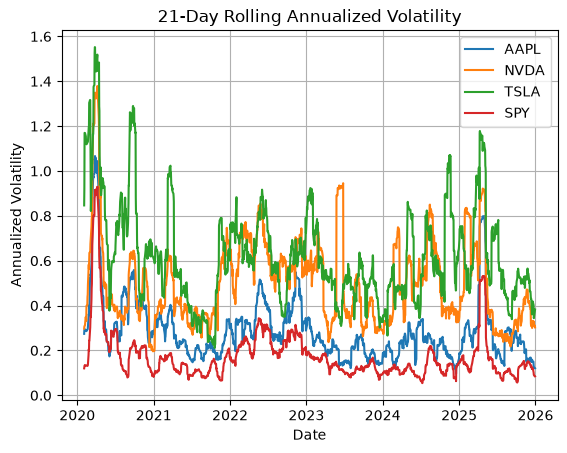

In [23]:
import matplotlib.pyplot as plt

for ticker in selected_tickers:
    stock_data = rolling_plot_data[
        rolling_plot_data["ticker"] == ticker
    ]

    plt.plot(
        stock_data["date"],
        stock_data["rolling_volatility_21d"],
        label=ticker
    )

plt.title("21-Day Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True)

plt.show()

In [24]:
plt.savefig(
    "../reports/rolling_volatility.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [25]:
import importlib
import data_utils

importlib.reload(data_utils)

<module 'data_utils' from '/Users/jiaxinlin/Documents/quant_internship/notebooks/../src/data_utils.py'>

In [26]:
performance_table_test = data_utils.performance_metrics(
    daily_returns
)

performance_table_test

,annualized_return,annualized_volatility,sharpe_ratio
ticker,,,
AAPL,0.272517,0.318192,0.730743
AMD,0.391182,0.539023,0.651515
AMZN,0.213653,0.357129,0.486246
AVGO,0.520508,0.439335,1.093715
BAC,0.157158,0.344137,0.340439
COST,0.225458,0.237545,0.780727
CSCO,0.143562,0.267332,0.387389
CVX,0.140922,0.339666,0.297121
DIS,0.016449,0.333095,-0.070704


In [27]:
performance_table_test.to_csv(
    "../reports/performance_table.csv"
)